# **3. Compuertas cuánticas**

# ***Computación y Programación Cuántica***


# **Bits**

Para sumar dos números con una computadora (como un teléfono inteligente o una laptop), primero los representamos en [_binario_](https://en.wikipedia.org/wiki/Binary_number). Los números binarios son de base 2. Estamos acostumbrados a la base 10, pero la base 2 (y la base 16) son muy útiles en informática. Un número de base 10 se ve así:

```
765 = 7 x 10^2 + 6 x 10^1 + 5 * 10^0
```

El dígito más a la derecha es 5 por diez elevado a cero. El siguiente dígito, a la izquierda, es 6 por diez elevado a uno. Finalmente, en el extremo izquierdo tenemos 7 por diez elevado a dos. Los números binarios son esencialmente iguales, pero en lugar de diez elevado a una potencia por posición, usamos dos elevado a una potencia:

```
0b101 = 1 x 2^2 + 0 x 2^1 + 1 x 2^0
```

Aquí, el dígito más a la derecha es 1 por dos elevado a cero. Hacia la izquierda, tenemos 0 por dos elevado a uno. Finalmente, en el extremo izquierdo, tenemos 1 por dos elevado a dos. En base 10, escribiríamos este número como "5". En base 10, los dígitos van del 0 al 9, y en base 2, del 0 al 1.

In [3]:
0b101

5

El sistema binario es útil para el cálculo con sistemas físicos porque podemos representar números binarios con sistemas de dos niveles, y estos sistemas son simples. Existen muchos sistemas electrónicos de dos niveles que podemos manipular rápidamente.

Así pues, configuramos un conjunto de registros con valores "positivos" (1) y "negativos" (0) (imaginemos pequeños imanes o diferentes niveles de voltaje, etc.). Luego, configuramos un tercer registro para almacenar el resultado (y uno para el "acarreo") e intercambiamos los valores positivos y negativos en el registro de resultados mediante un escaneo sobre el primer y el segundo registro (¡y el acarreo!), combinado con algunas reglas simples, y podemos sumar números:

<img src="https://www.dropbox.com/s/wgfi9lpl4qqbxv3/add_two_binary_numbers_rules.png?dl=1" height="90">

<img src="https://www.dropbox.com/s/dlkgen3tuk4hecv/add_three_binary_numbers_rules.png?dl=1" height="90">

Aquí sumamos 6 y 7:

<img src="https://www.dropbox.com/s/1rtvegu05pxfrab/binary_addition.png?dl=1" height="150">

In [4]:
0b110 + 0b111

13

In [5]:
bin(13)

'0b1101'

# **Compuertas lógicas**

Es razonable preguntar: "*Bien, una vez que se tienen estas reglas para la suma binaria, ¿cómo se implementan en hardware?*". ¿Dónde está el sistema físico que simula nuestro algoritmo?

Esta civilización ha descubierto cómo usar transistores para implementar puertas lógicas (https://en.wikipedia.org/wiki/Transistor–transistor_logic). Representamos estas puertas visualmente como circuitos: las líneas transportan datos (dígitos binarios clásicos: 0 y 1) y las puertas mismas son símbolos con entradas y salidas de línea. Usamos tablas de verdad para mostrar la acción de la puerta sobre los datos en la línea.

<img src="https://www.dropbox.com/s/2icjygcysqrkqeo/LogicCircuitsWithTables1.png?dl=1" alt="Logic circuits">

Algunas compuertas compuestas son tan populares que a menudo se construyen como primitivas:

<img src="https://www.dropbox.com/s/dkas7n803ypiz3e/LogicCircuitsWithTables2.png?dl=1" alt="Logic circuits">

# **Representación de los qubits: Esfera de Bloch**

Debido a que un qubit se escribe,

$$\vert\psi \rangle=\left[ \begin{array}{r} \alpha \\ \beta \end{array} \right]$$

con $\alpha,\beta\in\mathbb{C}$, es decir, necesita dos números complejos, y a su vez cada número complejo necesita de 2 números reales para poder escribirlo, entonces, necesitamos en total $4$ números reales para representar a un qubit.

$$\alpha=a+bi$$

$$\beta=c+di$$

donde $a,b,c,d \in \mathbb{R}$.

Parece que se tienen $4$ grados de libertad para un qubit, sin embargo, un grado de libertad deja de ser *libre* debido a la restricción de normalización: $|\alpha|^2 + |\beta|^2 = 1$. Tenemos ahora $3$ grados de libertad.

Entonces, utilizando una *transformación* de coordenadas conveniente, se puede eliminar ese grado de libertad, es decir, lograr la conversión de $\mathbb{R}^4\rightarrow\mathbb{R}^3$, mandando el espacio de $4$ dimensiones a la superficie de una esfera unitaria en $3$ dimensiones.

> **La esfera de Bloch** *es una representación geométrica de un sistema cuántico de dos niveles* (**un qubit**).

<div align="center">
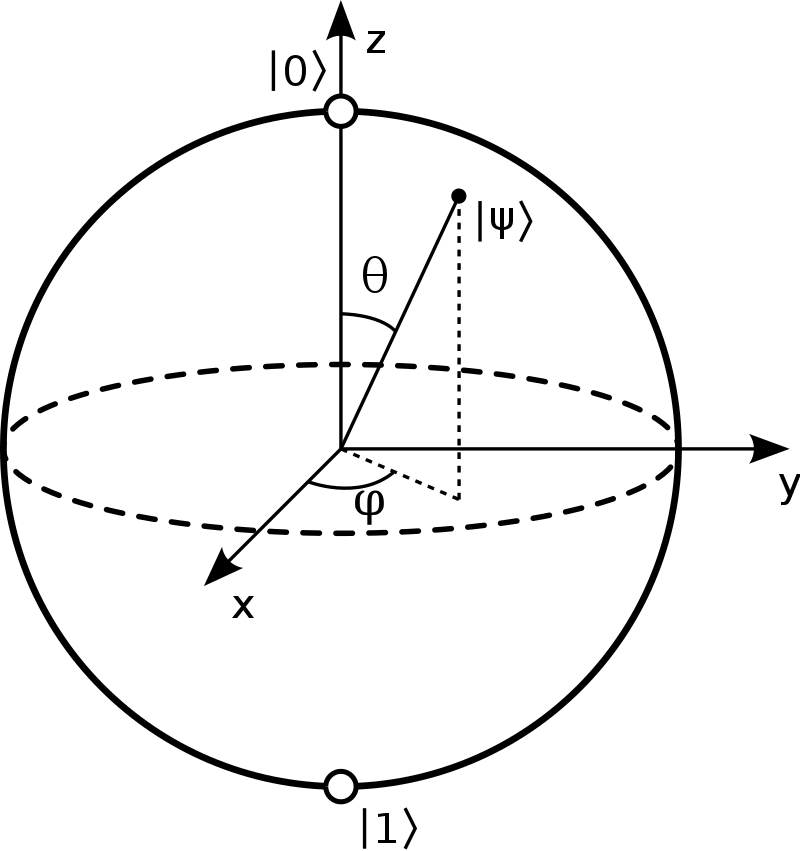

# **Representación de los qubits: Qiskit-IBM**

Se deben **instalar** los siguientes paquetes.

Al instalar desde un Jupyer Notebook, es usual usar `!` antes del comando `pip` para que la ejecución sea reconocida como un comando del **shell** y no como código de **Python**.

En **Google Colab**, siempre ejecutar la siguiente celda para instalar lo necesario.

In [6]:
#!pip install qiskit

In [7]:
#!pip install qiskit[visualization]

En Qiskit podemos crear qubits con la clase `QuantumRegister` como sigue:

In [8]:
from qiskit import QuantumRegister

In [9]:
qubit1 = QuantumRegister(1)         # el parámetro indica cuántos qubits queremos
qubit2 = QuantumRegister(1, 'qreg') # se puede indicar un nombre al registro cuántico (parámetro opcional)

La base que usa **Qiskit**, es la **base computacional**: $\{\vert 0\rangle, \vert 1\rangle\}$.

# **Circuito Cuántico**

Debemos tener en dónde usar los qubits, para eso contamos con el **circuito cuántico**.

> *Un circuito cuántico es un modelo de computación cuántica, similar a los circuitos clásicos, en los que una operación es una secuencia de compuertas cuánticas, mediciones, inicializaciones de qubits a valores conocidos y posiblemente otras acciones.*

Veamos cómo incluir en un circuito uno de los qubits que creamos anteriormente:

In [10]:
from qiskit import QuantumCircuit

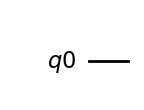

In [11]:
circuit = QuantumCircuit(qubit1) # crear un circuito cuántico con un qubit (previamente definido)
circuit.draw('mpl')              # mostramos la representación gráfica del circuito

$\textbf{Ejercicio:}$

Crea un **circuito cuántico** que genere un estado *Greenberger-Horne-Zeilinger* (GHZ) de 3 qubits:

\begin{equation}
\vert\psi\rangle=\frac{1}{\sqrt{2}}\left(\vert 000\rangle + \vert 111\rangle \right)
\end{equation}

Medir los qubits 0 y 2, almacenando los resultados en bits clásicos.

**Nota:** Como los tres qubits están **entrelazados**, los resultados de las mediciones estarán **correlacionados**.

**1. Crear el circuito cuántico**

`circ = QuantumCircuit(3, 2)`

Se define un circuito cuántico con:

3 qubits (índices 0, 1 y 2).

2 bits clásicos (índices 0 y 1), que se usarán para almacenar mediciones.

**2. Aplicar compuertas cuánticas**

`circ.h(0)`

Aplica la compuerta de Hadamard $H$ al qubit 0.

Esta compuerta genera una superposición, convirtiendo $\vert 0\rangle$ en:

\begin{equation}
H\vert 0\rangle = \frac{1}{\sqrt{2}}\left(\vert 0\rangle +\vert 1\rangle\right)
\end{equation}

`circ.cx(0, 1)`

Aplica una compuerta CNOT entre los qubits 0 (control) y 1 (objetivo).

Si el qubit 0 está en $\vert 1\rangle$, el qubit 1 cambiará de estado.

Dado que $q_{0}$ está en superposición, esta operación genera un **estado entrelazado** entre $q_{0}$ y $q_{1}$:

\begin{equation}
\frac{1}{\sqrt{2}}\left(\vert 00\rangle +\vert 11\rangle \right)
\end{equation}

`circ.cx(0, 2)`

Otra compuerta CNOT entre los qubits 0 (control) y 2 (objetivo).

Esto extiende el entrelazamiento al tercer qubit, formando un **estado GHZ:**

\begin{equation}
\vert\psi\rangle =\frac{1}{\sqrt{2}}\left(\vert 000\rangle +\vert 111\rangle \right)
\end{equation}

**3. Medición de los qubits**

`circ.measure(0, 1)`

Mide el qubit 0 y almacena el resultado en el bit clásico 1.

`circ.measure(2, 0)`

Mide el qubit 2 y almacena el resultado en el bit clásico 0.

**4. Dibujar el circuito**

`circ.draw('mpl')`

Dibuja el circuito usando matplotlib para una mejor visualización.

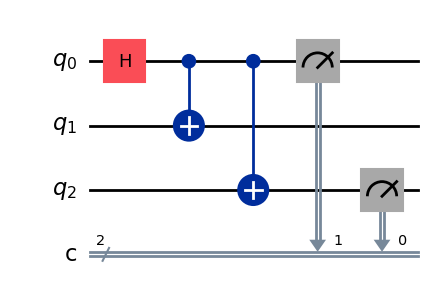

In [12]:
# 1. Crear el circuito cuántico
circ = QuantumCircuit(3, 2)

# 2. Aplicar compuertas cuánticas
circ.h(0)       # Hadamard en qubit 0
circ.cx(0, 1)   # CNOT de qubit 0 a qubit 1
circ.cx(0, 2)   # CNOT de qubit 0 a qubit 2

# 3. Medición de los qubits 0 y 2
circ.measure(0, 1)  # Medir qubit 0 y guardar en bit clásico 1
circ.measure(2, 0)  # Medir qubit 2 y guardar en bit clásico 0

# 4. Dibujar el circuito
circ.draw('mpl')

Es importante mencionar, que el tiempo ocurre de izquierda a derecha, entonces la compuerta $H$ es la que se aplica primero, y después la compuerta $CNOT_{0,1}$ y por último la compuerta $CNOT_{0,2}$, al final ocurren las mediciones.

Un importante punto a resaltar, es que *todos los qubits comienzan en el estado $\vert 0\rangle$.

# **Orden de los qubits**

En el circuito anterior se tienen 3 qubits: $q_0$, $q_1$ y $q_2$. Al momento de hacer la relación con las expresiones matemáticas, debemos tomar en cuenta que, un estado de tres qubits tendrá el siguiente orden (respecto a la convención de Qiskit):

$$\vert q_{2},q_{1},q_{0}\rangle=\vert 000\rangle$$

# **Compuerta Cuántica**

Una vez que tenemos qubits en un circuito cuántico, lo siguiente es manipularlos, para lograr un objetivo, implementar algoritmos cuánticos. Esta manipulación de hace con las **compuertas cuánticas**.

> *Las compuertas cuánticas son operadores unitarios y se describen como matrices unitarias en relación con alguna base. Usualmente se usa la base computacional.*

Las compuertas cuánticas son los componentes básicos de los circuitos cuánticos, como lo son las compuertas lógicas clásicas para los circuitos digitales convencionales. A diferencia de muchas compuertas lógicas clásicas, las compuertas lógicas cuánticas son **reversibles**.

# **Compuertas de un sólo qubit**

$\textbf{Compuertas de Pauli}$

Las **compuertas de Pauli** son las tres [matrices de Pauli](https://en.wikipedia.org/wiki/Pauli_matrices) ($\sigma_x, \sigma_y,\sigma_z$) y actúan sobre un solo quibit.

Las compuertas $X$, $Y$, $Z$, respectivamente, equivalen a una rotación de $\pi$ radianes (180°) al rededor del eje $x$, $y$, $z$ en la *esfera de Bloch*.

$\textbf{Compuerta X}$

Esta compuerta es equivalente a la compuerta de negación ($NOT$) en las computadoras clásicas.

También es llamada *bit-flip* ya que mapea los estados base como sigue:

$$X\vert 0\rangle = \vert 1\rangle$$

$$X\vert 1\rangle = \vert 0\rangle$$

Su representación matricial es,

$$X = \text{NOT} =
\begin{bmatrix}
    0 & 1 \\
    1 & 0
\end{bmatrix}
$$

### **Ejemplo:**

Efecto de la compuerta $X$ sobre el estado $\vert 1\rangle$
    
$$X\vert 1\rangle =
\begin{bmatrix}
    0 & 1 \\
    1 & 0
\end{bmatrix}
\begin{bmatrix}
    0 \\
    1
\end{bmatrix}
=
\begin{bmatrix}
    1 \\
    0
\end{bmatrix}
= \vert 0\rangle
$$

En Qiskit aplicamos la compuerta $X$ con el método `x()`:

# **Obtener el vector de estado con Qiskit**

Con la clase `Statevector` de Qiskit, se puede obtener el estado de un circuito en el punto que se desee:

In [13]:
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import array_to_latex

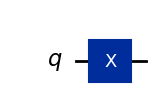

👉 Estado inicial (|0⟩):
➤ en forma de vector:


<IPython.core.display.Latex object>

➤ en forma de ket:


<IPython.core.display.Latex object>

👉 Estado después de aplicar X:
➤ en forma de vector:


<IPython.core.display.Latex object>

➤ en forma de ket:


<IPython.core.display.Latex object>

🧮 Matriz de la compuerta X como Operator:


<IPython.core.display.Latex object>

In [14]:
# Estado inicial |0>
psi_0 = Statevector.from_label('0')

# Crear circuito con compuerta X
circ1 = QuantumCircuit(1)
circ1.x(0)

# Aplicar la compuerta X al estado
psi_1 = psi_0.evolve(circ1)

# Mostrar el circuito
display(circ1.draw('mpl'))

# Mostrar el estado inicial
print("👉 Estado inicial (|0⟩):")
print("➤ en forma de vector:")
display(array_to_latex(psi_0.data))
print("➤ en forma de ket:")
display(psi_0.draw('latex'))

# Mostrar el estado después de aplicar X
print("👉 Estado después de aplicar X:")
print("➤ en forma de vector:")
display(array_to_latex(psi_1.data))
print("➤ en forma de ket:")
display(psi_1.draw('latex'))

# Mostrar la compuerta X como matriz (Operator)
op_x = Operator(circ1)
print("🧮 Matriz de la compuerta X como Operator:")
display(array_to_latex(op_x.data))

# **Visualización en la esfera de Bloch con Qiskit**

Con la función `plot_bloch_multivector()` podemos visualizar un qubit, indicando el vector de estado.

In [15]:
from qiskit.visualization import plot_bloch_multivector

🔵 Estado inicial:


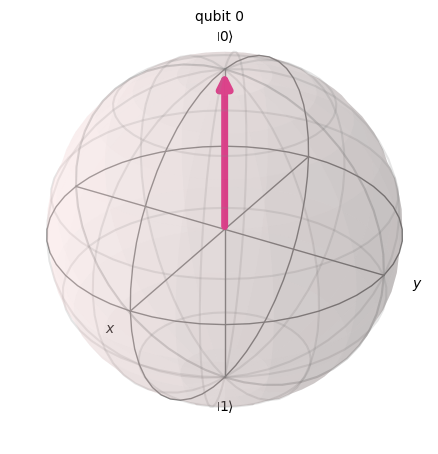

🔵 Estado después de X:


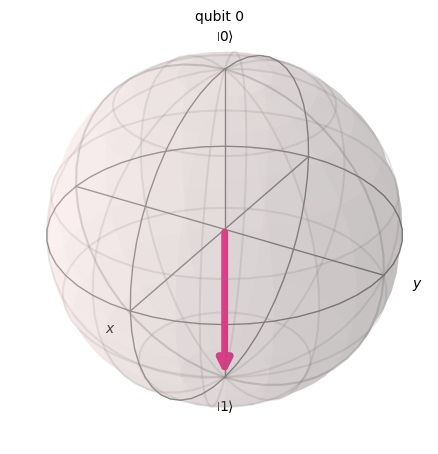

In [16]:
print("🔵 Estado inicial:")
display(plot_bloch_multivector(psi_0))

print("🔵 Estado después de X:")
display(plot_bloch_multivector(psi_1))

$\textbf{Compuerta $Y$}$

Esta compuerta mapea los estados base como sigue:

$$Y\vert 0\rangle=i\vert 1\rangle$$
$$Y\vert 1\rangle=-i\vert 0\rangle$$

Su representación matricial es,

$$Y=\begin{bmatrix}
    0 & -i \\
    i & 0
\end{bmatrix}$$

En Qiskit aplicamos la compuerta $Y$ con el método `y()`.

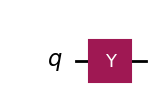

In [17]:
qcy = QuantumCircuit(1)

qcy.y(0)

qcy.draw('mpl')

$\textbf{Compuerta $Z$}$

Esta compuerta mapea los estados base como sigue:

$$Z\vert 0\rangle=\vert 0\rangle$$
$$Z\vert 1\rangle=-\vert 1\rangle$$

Su representación matricial es,

$$Z=\begin{bmatrix}
    1 & 0 \\
    0 & -1
\end{bmatrix}$$

En Qiskit aplicamos la compuerta $Z$ con el método `z()`.

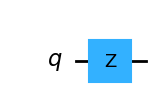

In [18]:
qcz = QuantumCircuit(1)

qcz.z(0)

qcz.draw('mpl')

# **Compuertas de rotación**

Las compuertas de Pauli son rotaciones de $\pi$ radianes, pero podemos hacer que el estado cuántico rote con otros ángulos, para ello, tenemos las compuertas de rotaciones, alrededor de los ejes, definidas como sigue:

$$R_x(\phi) =
\begin{bmatrix}
\cos\left(\frac{\phi}{2}\right) & -i\sin\left(\frac{\phi}{2}\right) \\
-i\sin\left(\frac{\phi}{2}\right) & \cos\left(\frac{\phi}{2}\right)
\end{bmatrix}$$

$$R_y(\phi) =
\begin{bmatrix}
\cos\left(\frac{\phi}{2}\right) & -\sin\left(\frac{\phi}{2}\right) \\
\sin\left(\frac{\phi}{2}\right) & \cos\left(\frac{\phi}{2}\right)
\end{bmatrix}$$

$$R_z(\phi) =
\begin{bmatrix}
e^{-i\frac{\phi}{2}} & 0 \\
0 & e^{i\frac{\phi}{2}}
\end{bmatrix}$$




En Qiskit existen los métodos `rx()`, `ry()` y `rz()` para lograr las rotaciones con diferentes ángulos.

# **Compuerta Hadamard**



La compuerta Hadamard crea un estado de superposición de la base computacional $\{\vert 0\rangle, \vert 1\rangle\}$, entonces mapea los estados como sigue,

$$H\vert 0\rangle = \vert +\rangle =
\frac{1}{\sqrt{2}}\begin{bmatrix}
1 \\
1
\end{bmatrix}$$

$$H\vert 1\rangle = \vert -\rangle =
\frac{1}{\sqrt{2}}\begin{bmatrix}
1 \\
-1
\end{bmatrix}$$


La compuerta Hadamard también es una rotación, pero alrededor del eje $\frac{\left(\hat{x}+\hat{z}\right)}{\sqrt{2}}$, es decir, el eje en el plano $xz$ con 45° del estado $\vert 0\rangle$

<div align="center">
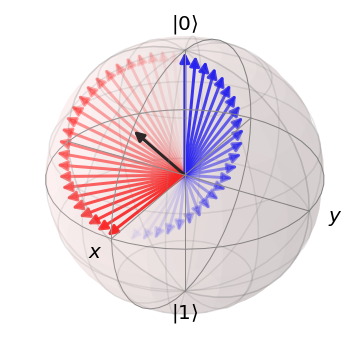

Su representación matricial es,

$$H =\frac{1}{\sqrt{2}} \begin{bmatrix}1 & 1 \\
 1 & -1\end{bmatrix}$$

En Qiskit aplicamos la compuerta $H$ con el método `h()`.

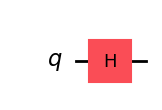

In [19]:
circ_h = QuantumCircuit(1)

circ_h.h(0)                   # aplicar compuerta H al qubit 0

circ_h.draw('mpl')            # mostrar el circuito

In [20]:
Statevector(circ_h).draw('latex', max_size=16)

<IPython.core.display.Latex object>

# **Compuertas de múltiples qubits**

$\textbf{Sistemas con más de un qubit}$

Hemos visto algunos efectos con qubits individuales y compuertas de un qubit, pero el verdadero poder de la computación cuántica se realiza a través de las interacciones entre qubits.

Por lo general, las compuertas que se pueden **implementar directamente en el hardware actuarán solo en uno o dos qubits**.

En nuestros circuitos, podemos querer usar compuertas complejas que actúen sobre una gran cantidad de qubits. Afortunadamente, esto no será un problema. Con las compuertas de uno y dos qubits que nos proporciona el hardware, es posible construir cualquier otra compuerta.

$\textbf{Estados multi-qubit}$

La dimensión del espacio de Hilbert para $n$ qubits está dado por $2^n$. Para obtenerlo se usa el **producto tensorial** (o [producto de Kronecker](https://en.wikipedia.org/wiki/Kronecker_product)).

El producto tensorial, denotado por $\otimes$, se puede aplicar a vectores y matrices (en general a [tensores](https://en.wikipedia.org/wiki/Tensor)).

**El espacio de 2 qubits**

El espacio de Hilbert de un estado cuántico formado por dos qubits, $n=2$, tendrá una dimensión de $2^2=4$. Por ejemplo, el estado formado por dos qubits, cada uno en el estado $\vert 0\rangle$ es,

$$\vert 0\rangle\otimes\vert 0\rangle=\vert 00\rangle=\begin{bmatrix} 1 \\ 0 \end{bmatrix}\otimes\begin{bmatrix} 1 \\ 0 \end{bmatrix} =\begin{bmatrix} 1 \begin{bmatrix} 1 \\ 0\end{bmatrix}  \\ 0 \begin{bmatrix} 1 \\ 0\end{bmatrix}\end{bmatrix} =\begin{bmatrix} 1 \\ 0 \\ 0 \\ 0 \end{bmatrix}$$

Ahora, considerando todas las posibles combinaciones de los estados base para cada uno de los dos qubits, tenemos que,

$$\vert 0\rangle\otimes\vert 0\rangle=\vert 00\rangle =\begin{bmatrix} 1 \\ 0 \\ 0 \\ 0 \end{bmatrix}$$

$$\vert 0\rangle\otimes\vert 1\rangle=\vert 01\rangle =\begin{bmatrix} 0 \\ 1 \\ 0 \\ 0 \end{bmatrix}$$

$$\vert 1\rangle\otimes\vert 0\rangle=\vert 10\rangle =\begin{bmatrix} 0 \\ 0 \\ 1 \\ 0 \end{bmatrix}$$

$$\vert 1\rangle\otimes\vert 1\rangle=\vert 11\rangle =\begin{bmatrix} 0 \\ 0 \\ 0 \\ 1 \end{bmatrix}$$

$\textbf{Compuertas de un qubit en estados multi-qubit}$

Las compuertas de un solo qubit que actúan en estados multi-qubit, deben tener la dimension correcta para poder efectuar la multiplicación matriz por vector.

Si por ejemplo tenemos esto: $H\vert q_{1}q_{0}\rangle$, no se puede saber a cual de los dos qubits se le debe aplicar la compuerta $H$ si a $\vert q_{1}\rangle$ o a $\vert q_{0}\rangle$, entonces se debe ser explícito. Si lo que se desea es aplicar $H$ al $\vert q_{0}\rangle$ se debe escribir:

$$I\otimes H \; \vert q_{1}q_{0} \rangle$$

Lo que implica que se aplicará la compuerta *identidad* al $\vert q_{1}\rangle$, es decir, no será afectado.

La compuerta $I\otimes H$ a aplicar al estado de 2 qubits es:


$$ I \otimes H =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
\otimes
\begin{bmatrix}
\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\
\frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
\end{bmatrix}
=
\begin{bmatrix}
1 \cdot H & 0 \cdot H \\
0 \cdot H & 1 \cdot H
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} & 0 & 0 \\
\frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 & 0 \\
0 & 0 & \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\
0 & 0 & \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
\end{bmatrix}$$


En Qiskit podemos usar la clase `Operator` para obtener el operador equivalente a las compuertas agregadas a un circuito, veamos le ejemplo anterior:

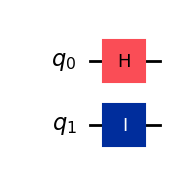

<IPython.core.display.Latex object>

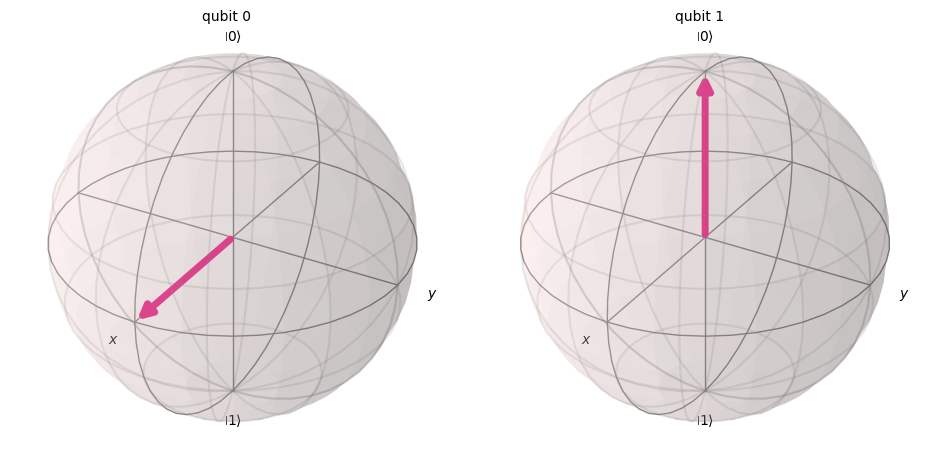

In [21]:
circuit = QuantumCircuit(2) # circuito con 2 qubits

circuit.h(0)    # Hadamard en q0
circuit.id(1)   # Identidad en q1

display(circuit.draw('mpl'))

op = Operator(circuit)
display(array_to_latex(op))

psi = Statevector(circuit)

display(plot_bloch_multivector(psi))

### **Ejercicio:**

Consideremos el siguiente circuito con apenas 3 qubits y 3 compuertas cuánticas $\vert q_2 \, q_1 \, q_0\rangle$:

$$H\otimes R_y(3\pi/5) \otimes R_x(\pi/4) \; \vert 000\rangle.$$

Construye el circuito cuántico, el vector de estado, el operador unitario y la representación de la esfera de Bloch para cada qubit.

In [22]:
import numpy as np

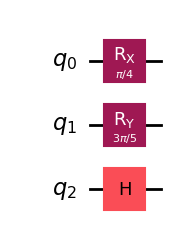


Vector de estado:
Statevector([0.38398922+0.j        , 0.        -0.15905354j,
             0.52851582+0.j        , 0.        -0.21891842j,
             0.38398922+0.j        , 0.        -0.15905354j,
             0.52851582+0.j        , 0.        -0.21891842j],
            dims=(2, 2, 2))

Operador unitario:
Operator([[ 0.38398922+0.j        ,  0.        -0.15905354j,
           -0.52851582+0.j        ,  0.        +0.21891842j,
            0.38398922+0.j        ,  0.        -0.15905354j,
           -0.52851582+0.j        ,  0.        +0.21891842j],
          [ 0.        -0.15905354j,  0.38398922+0.j        ,
            0.        +0.21891842j, -0.52851582+0.j        ,
            0.        -0.15905354j,  0.38398922+0.j        ,
            0.        +0.21891842j, -0.52851582+0.j        ],
          [ 0.52851582+0.j        ,  0.        -0.21891842j,
            0.38398922+0.j        ,  0.        -0.15905354j,
            0.52851582+0.j        ,  0.        -0.21891842j,
            0.3

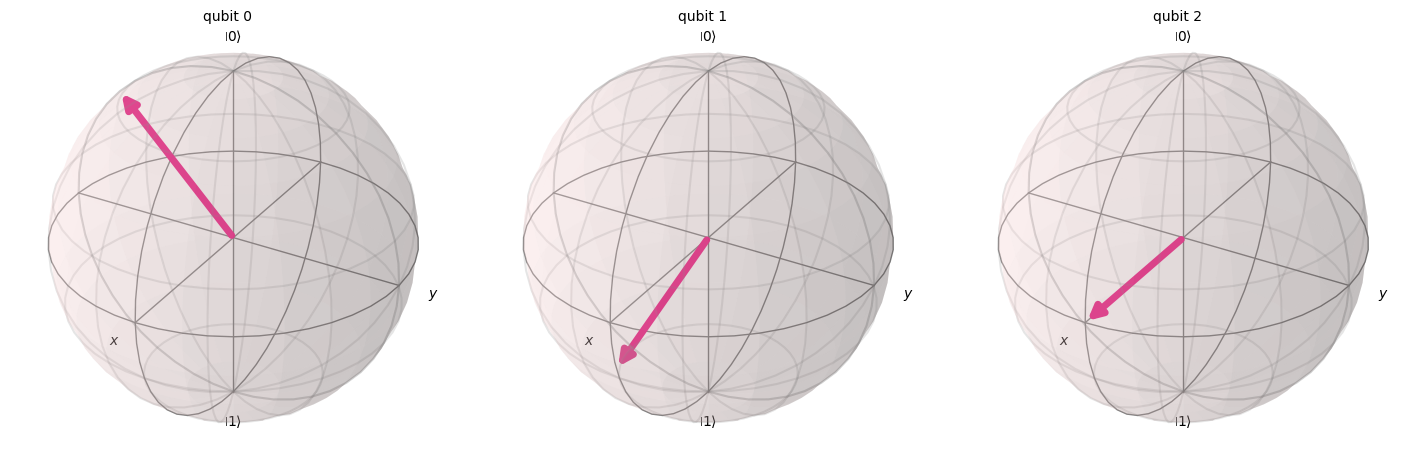

In [23]:
# Crear el circuito cuántico con 3 qubits
circuit = QuantumCircuit(3)

# Aplicar las compuertas: H en q2, Ry(3π/5) en q1, Rx(π/4) en q0
circuit.h(2)  # Hadamard en qubit 2
circuit.ry(3*np.pi/5, 1)  # Ry(3π/5) en qubit 1
circuit.rx(np.pi/4, 0)  # Rx(π/4) en qubit 0

# Mostrar el circuito
display(circuit.draw('mpl'))

# Obtener el vector de estado
psi = Statevector(circuit)
print("\nVector de estado:")
print(psi)

# Obtener el operador unitario
unitary = Operator(circuit)
print("\nOperador unitario:")
print(unitary)

# Representación en la esfera de Bloch para cada qubit
print("\nRepresentación en la esfera de Bloch:")
display(plot_bloch_multivector(psi))

# **Compuertas de dos qubits**

Ahora que ya sabemos cómo son los estados multi-qubit, podemos revisar las compuertas que son aplicadas a más de un qubit. Primero veamos algunas compuertas que necesitan dos qubits para operar.

$\textbf{Compuerta $CNOT$ o $CX$}$

Se trata de una compuerta controlada, actúa sobre dos qubits, en donde uno de ellos sirve como control y el otro como el objetivo.

Se aplicará una operación $NOT$ o $X$ en el qubit objetivo, solo cuando el qubit control sea $\vert 1\rangle$.

Si el qubit de la izquierda ($\vert q_1\rangle$) es el control y el de la derecha ($\vert q_{0}\rangle$) es el objetivo, en el estado $\vert q_1 q_0\rangle$, las transiciones son:

$$CNOT_{1,0}\vert 00\rangle=\vert 00\rangle$$
$$CNOT_{1,0}\vert 01\rangle=\vert 01\rangle$$
$$CNOT_{1,0}\vert 10\rangle=\vert 11\rangle$$
$$CNOT_{1,0}\vert 11\rangle=\vert 10\rangle$$

donde los subíndices en $CNOT$ indican el qubit control y el objetivo, en ese orden.

*El orden predeterminado en la mayoría de las referencias es que **el qubit de la izquierda es el control**, mientras que **el de la derecha es el objetivo**.*

En Qiskit se cuenta con el método `cx(c, t)`, que recibe el qubit de control como primer parámetro y el qubit objetivo como segundo parámetro.

Este es el caso para CNOT(1,0)|10> = |11>


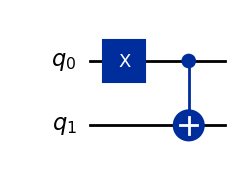

<IPython.core.display.Latex object>

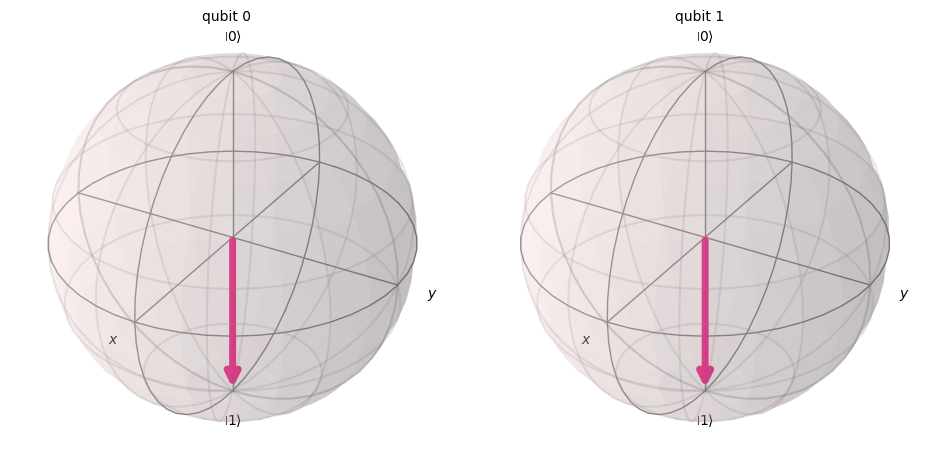

In [24]:
circ7 = QuantumCircuit(2)   # circuito con 2 qubits

circ7.x(0)                  # ponemos el control en |1> para que la compuerta sea aplicada

circ7.cx(0, 1)              # CNOT con q0 como control y q1 como objetivo

print("Este es el caso para CNOT(1,0)|10> = |11>")

display(circ7.draw('mpl'))

psi = Statevector(circ7)

op = Operator(circ7)
display(array_to_latex(op))

print()
display(plot_bloch_multivector(psi))

# **Compuertas controladas**

Así como podemos controlar si aplicar la compuerta $X$ de acuerdo al estado de un qubit control, podemos controlar cualquier otra compuerta. Si tenemos la compuerta $U$, su versión controlada sería $CU$, y podemos decidir cual qubit es el control y cual es el objetivo (como para el caso de $CNOT$).

Una operación unitaria en general la podemos escribir como,

$$U =\begin{bmatrix}u_{11} & u_{12} \\ u_{21} & u_{22}\end{bmatrix}$$

$$U=u_{11}\vert 0\rangle\langle 0\vert+u_{12}\vert 0\rangle\langle 1\vert+u_{21}\vert 1\rangle\langle 0\vert+u_{22}\vert 1\rangle\langle 1\vert$$

Entonces su versión controlada $CU$, si el control es el qubit de la izquierda ($\vert q_1\rangle$), tendría las transiciones:

$CU_{1,0}\vert 00\rangle=\vert 00\rangle$

$CU_{1,0}\vert 01\rangle=\vert 01\rangle$

$CU_{1,0}\vert 10\rangle=\vert 1\rangle\otimes U\vert 0\rangle=\vert 1\rangle\otimes \left(u_{11}\vert 0\rangle+u_{21}\vert 1\rangle\right)$

$CU_{1,0}\vert 11\rangle=\vert 1\rangle\otimes U\vert 1\rangle=\vert 1\rangle\otimes \left(u_{12}\vert 0\rangle+u_{22}\vert 1\rangle\right)$

Su forma matricial es,

$$CU= \begin{bmatrix}1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & u_{11} & u_{12} \\ 0 & 0 & u_{21} & u_{22}\end{bmatrix}$$

De acuerdo lo anterior, para construir la compuerta $CNOT$ o $CX$ deberiamos considerar que $U$ es decir $X$

$$X=\begin{bmatrix} 0 & 1 \\ 1 & 0\end{bmatrix}$$

lo que significa que $u_{11}=u_{22}=0$ y $u_{12}=u_{21}=1$. Por lo tanto $CX$ es de forma **teórica**

$$CX= \begin{bmatrix}1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0\end{bmatrix}$$

### **Ejemplo:**

Construye las compuertas $CX, CY$ y $CZ$

Matriz de la compuerta CX en notación LaTeX:


<IPython.core.display.Latex object>


 Circuito cuántico con la compuerta CX:


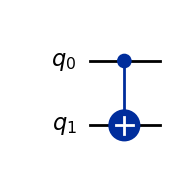

In [25]:
# 1. Creamos un circuito cuántico con 2 qubits
qc = QuantumCircuit(2)

# 2. Aplicamos la compuerta CNOT (CX) con el qubit 0 como control y el qubit 1 como objetivo
qc.cx(0, 1)

# 3. Obtenemos la matriz correspondiente generada automáticamente
CX_operator = Operator(qc)

# 4. Mostramos la matriz de la compuerta CX en formato LaTeX
print("Matriz de la compuerta CX en notación LaTeX:")
display(array_to_latex(CX_operator, precision=0))

# 5. Mostramos el circuito cuántico gráficamente
print("\n Circuito cuántico con la compuerta CX:")
display(qc.draw('mpl'))


# **¿Por qué la matriz $CX$ se ve diferente en Qiskit?**

En teoría, la matriz de la compuerta $CNOT$ $(CX)$ se define como:

$$CX= \begin{bmatrix}1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0\end{bmatrix}$$

**Sin embargo, en Qiskit, la matriz generada automáticamente tiene los índices de los qubits en el orden inverso** debido a que usa *little-endian*, es decir, el qubit de menor índice está a la derecha, no a la izquierda.

$\textbf{¿Cómo afecta esto a la matriz $CX$?}$

En **big-endian** (convención teórica estándar), el estado $\vert 01\rangle$ está en la tercera fila y el estado $\vert 10\rangle$ en la segunda.

En **little-endian** (usado por Qiskit), los índices se invierten, por lo que el orden de las filas y columnas se reorganiza.

Matriz de la compuerta CY en notación LaTeX:


<IPython.core.display.Latex object>


 Circuito cuántico con la compuerta CY:


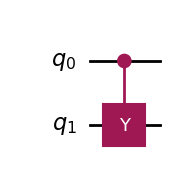

In [26]:
# 1. Creamos un circuito cuántico con 2 qubits
qc = QuantumCircuit(2)

# 2. Aplicamos la compuerta CY con el qubit 0 como control y el qubit 1 como objetivo
qc.cy(0, 1)

# 3. Obtenemos la matriz correspondiente generada automáticamente
CY_operator = Operator(qc)

# 4. Mostramos la matriz de la compuerta CY en formato LaTeX
print("Matriz de la compuerta CY en notación LaTeX:")
display(array_to_latex(CY_operator, precision=0))

# 5. Mostramos el circuito cuántico gráficamente
print("\n Circuito cuántico con la compuerta CY:")
display(qc.draw('mpl'))

Matriz de la compuerta CZ en notación LaTeX:


<IPython.core.display.Latex object>


 Circuito cuántico con la compuerta CZ:


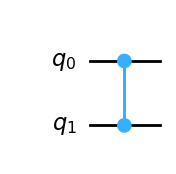

In [27]:
# 1. Creamos un circuito cuántico con 2 qubits
qc = QuantumCircuit(2)

# 2. Aplicamos la compuerta CY con el qubit 0 como control y el qubit 1 como objetivo
qc.cz(0, 1)

# 3. Obtenemos la matriz correspondiente generada automáticamente
CZ_operator = Operator(qc)

# 4. Mostramos la matriz de la compuerta CZ en formato LaTeX
print("Matriz de la compuerta CZ en notación LaTeX:")
display(array_to_latex(CZ_operator, precision=0))

# 5. Mostramos el circuito cuántico gráficamente
print("\n Circuito cuántico con la compuerta CZ:")
display(qc.draw('mpl'))

### **Ejercicio:**

En Qiskit existen varias compuertas controladas predefinidas. Del siguiente circuito cuántico, programa las compuertas cuánticas necesarias para construirlo y comprueba que efectivamente es el indicado:

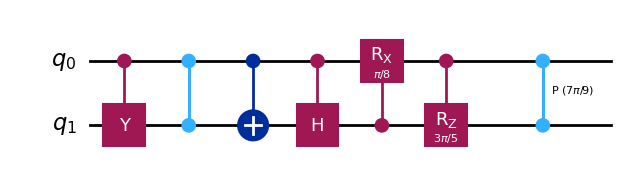

# **Simulación de Circuitos Cuánticos en Computadoras Clásicas**

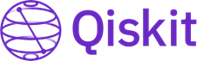

[Qiskit](https://www.ibm.com/quantum/qiskit) es un framework de [IBM Quantum](https://www.ibm.com/quantum) para el desarrollo de programas de computación cuántica. Permite crear, simular y ejecutar circuitos cuánticos en hardware cuántico y clásico. Vamos a comenzar con un ejemplo práctico.

En este ejemplo, vamos a crear un circuito cuántico sencillo en Qiskit que aplica una compuerta Hadamard a un qubit y luego una compuerta CNOT a dos qubits. Esto genera un [estado de Bell](https://en.wikipedia.org/wiki/Bell_state).

Instalación de Qiskit (Ejecutar solo una vez)

`!pip install qiskit[visualization]`

In [28]:
# Instalar el simulador Aer por separado (Ejecutar solo una vez)
!pip install qiskit-aer

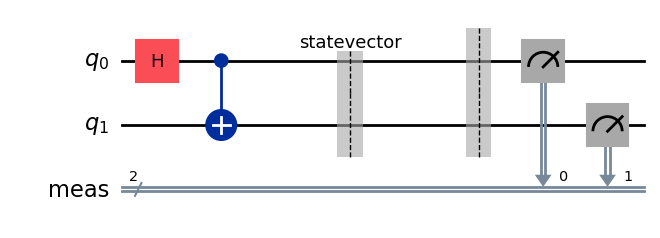

In [29]:
# Importar módulos necesarios
from qiskit import transpile
from qiskit_aer import AerSimulator

# Crear un circuito cuántico sencillo
qc = QuantumCircuit(2)  # Crear un circuito con 2 qubits
qc.h(0)                 # Aplicar una compuerta Hadamard al primer qubit
qc.cx(0, 1)             # Aplicar una compuerta CNOT (control en qubit 0, target en qubit 1)
qc2 = qc.copy()         # Copiar el circuito recién creado
qc.save_statevector()   # Guardar el vector de estado al final del circuito
qc.measure_all()        # Medir (colapsar) todos los qubits

# Visualizar el circuito
qc.draw('mpl')

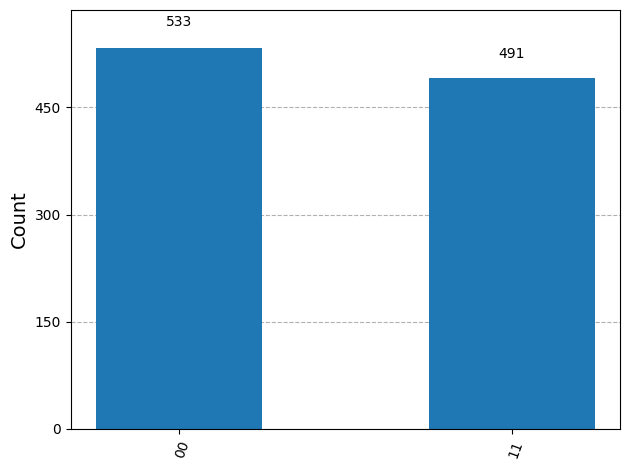

In [30]:
from qiskit.visualization import plot_histogram

# Simular el circuito usando AerSimulator
simulator_aer = AerSimulator()
# Ejecutar el circuito n veces
job = simulator_aer.run(qc, shots=1024)      # no hay necesidad de traspilar cuando se usan compuertas cuánticas estándar

# Obtener y mostrar los resultados
counts = job.result().get_counts(qc)
plot_histogram(counts)

In [31]:
# Más información

qc2.save_unitary()
simulator_aer2 = AerSimulator(method='unitary')
job2 = simulator_aer2.run(qc2, shots=1024)

print()
print(f'-- Conteos: \n \t\t\t\t\t\t\t{counts}')
print('-- Vector de estado: ')
display(job.result().get_statevector().draw('latex'))
print('-- Matriz unitaria: ')
display(job2.result().get_unitary().draw('latex'))


-- Conteos: 
 							{'00': 533, '11': 491}
-- Vector de estado: 


<IPython.core.display.Latex object>

-- Matriz unitaria: 


<IPython.core.display.Latex object>

Recordemos que:

$$|00\rangle = \begin{bmatrix}1\\0\\0\\0\end{bmatrix},\quad |01\rangle = \begin{bmatrix}0\\1\\0\\0\end{bmatrix},\quad |10\rangle = \begin{bmatrix}0\\0\\1\\0\end{bmatrix},\quad |11\rangle = \begin{bmatrix}0\\0\\0\\1\end{bmatrix}$$

Entonces,

$$\frac{1}{\sqrt2}|00\rangle + \frac{1}{\sqrt2}|11\rangle = \frac{1}{\sqrt2}\begin{bmatrix}1\\0\\0\\1\end{bmatrix}$$

Notemos que,

$$\frac{\sqrt2}{2}=\frac{1}{\sqrt2}=0.70710678$$

Entonces la matriz unitaria obtenida se puede reeescribir como:

$$\frac{1}{\sqrt2}\begin{bmatrix}1&1&0&0\\0&0&1&-1\\0&0&1&1\\1&-1&0&0\end{bmatrix}$$

$$ $$

El ejemplo anterior es realmente sencillo y es relativamente fácil calcular su vector de estado final y la matriz unitaria que representa al circuito cuántico completo, pero el cálculo de estos vectores y matrices se vuelve complicado rápidamente.

[PennyLane](https://pennylane.ai/) es un framework que integra la computación cuántica con el _machine learning_ creado por [Xanadu](https://xanadu.ai/). También permite crear circuitos cuánticos y ejecutarlos en simuladores y hardware cuántico real. Realicemos el mismo ejemplo pero usando esta otra librería.

Crearemos un circuito cuántico sencillo en Pennylane que aplica una compuerta Hadamard a un qubit y luego una compuerta CNOT a dos qubits. Esto genera un [estado de Bell](https://en.wikipedia.org/wiki/Bell_state).

In [32]:
# Instalación de PennyLane (Ejecutar solo una vez)
!pip install pennylane

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached charset_normalizer-3.4.4-cp311-cp311-win_amd64.whl.metadata (38 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.2-py3-none-any.whl.metadata (6.6 kB)
  Using cached certifi-2025.11.12-py3-none-any.whl.metadata (2.5 kB)
   ---------------------------------------- 0.0/5.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.3 MB ? eta -:--:--
   ----- ---------------------------------- 0.8/5.3 MB 3.0 MB/s eta 0:00:02
   --------- ------------------------------ 1.3/5.3 MB 2.7 MB/s eta 0:00:02
   ------------- -------------------------- 1.8/5.3 MB 2.6 MB/s eta 0:00:02
   ----------------- ----------

0: ──H─╭●─┤  Counts
1: ────╰X─┤  Counts


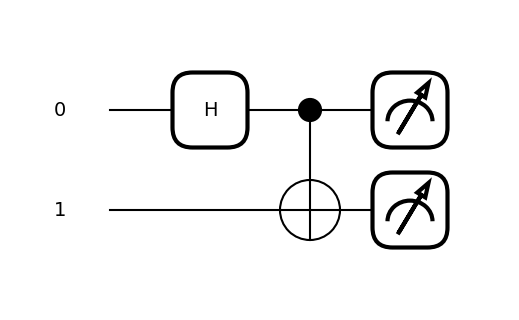

In [33]:
import pennylane as qml
from pennylane import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Configurar un dispositivo para la simulación
dev = qml.device('default.qubit', wires=2, shots=1024)

# Definir un circuito cuántico con una función
@qml.qnode(dev)
def my_circuit():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.counts()

# Visualizar el circuito
fig, ax = qml.draw_mpl(my_circuit)()
fig.show()

drawer = qml.draw(my_circuit)
print(drawer())

El vector del circuito anterior esta dado pr:

$$\frac{1}{\sqrt2}|00\rangle + \frac{1}{\sqrt2}|11\rangle = \frac{1}{\sqrt2}\begin{bmatrix}1\\0\\0\\1\end{bmatrix}$$

Que es igual a lo obtenido con Qiskit.

In [34]:
# Obtener la matriz unitaria que representa al circuito
qml.matrix(my_circuit)()

array([[ 0.70710678,  0.        ,  0.70710678,  0.        ],
       [ 0.        ,  0.70710678,  0.        ,  0.70710678],
       [ 0.        ,  0.70710678,  0.        , -0.70710678],
       [ 0.70710678,  0.        , -0.70710678,  0.        ]])

La matriz anterior se puede escribir como:

$$\frac{1}{\sqrt2}\begin{bmatrix}1&0&1&0\\0&1&0&1\\0&1&0&-1\\1&0&-1&0\end{bmatrix}$$

Y observamos que es diferente a la que nos indicó Qiskit. Esto se debe a que el orden de los qubits es inverso entre estas dos librerías.

Si el qubit superior en el circuito cuántico es $|q_0\rangle$ y el inferior es $|q_1\rangle$, entonces tenemos que,

- Qiksit define el estado como:
$$|q_1q_0\rangle$$
- Pennylane define el estado como:
$$|q_0q_1\rangle$$

Así, para obtener la misma matriz unitaria, debemos crear el circuito en el orden inverso en Pennylane:

In [35]:
# Definir un circuito cuántico con una función intercambiando el orden de los qubits
@qml.qnode(dev)
def my_circuit3():
    qml.Hadamard(wires=1)
    qml.CNOT(wires=[1, 0])
    return qml.counts()

# Visualizar el circuito
drawer = qml.draw(my_circuit3)
print(drawer())
print()

# Obtener la matriz unitaria que representa al circuito
qml.matrix(my_circuit3)()

0: ────╭X─┤  Counts
1: ──H─╰●─┤  Counts



array([[ 0.70710678,  0.70710678,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.70710678, -0.70710678],
       [ 0.        ,  0.        ,  0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678,  0.        ,  0.        ]])

La matriz anterior se puede escribir como:

$$\frac{1}{\sqrt2}\begin{bmatrix}1&1&0&0\\0&0&1&-1\\0&0&1&1\\1&-1&0&0\end{bmatrix}$$

La cual si coincide con la matriz que indicó Qiskit.

$$ $$

$$ $$